# 1. Import Libraries

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# 2. Importing Data

In [17]:
df = pd.read_csv('Loan.csv')
df.head()

,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1


# 3. EDA

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  5000 non-null   int64  
 1   Age                 5000 non-null   int64  
 2   Experience          5000 non-null   int64  
 3   Income              5000 non-null   int64  
 4   ZIP Code            5000 non-null   int64  
 5   Family              5000 non-null   int64  
 6   CCAvg               5000 non-null   float64
 7   Education           5000 non-null   int64  
 8   Mortgage            5000 non-null   int64  
 9   Personal Loan       5000 non-null   int64  
 10  Securities Account  5000 non-null   int64  
 11  CD Account          5000 non-null   int64  
 12  Online              5000 non-null   int64  
 13  CreditCard          5000 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 547.0 KB


Tidak ada data yang kosong dan tidak ada juga data yang harus di encoding

In [19]:
correlation = df.corr()

<Axes: >

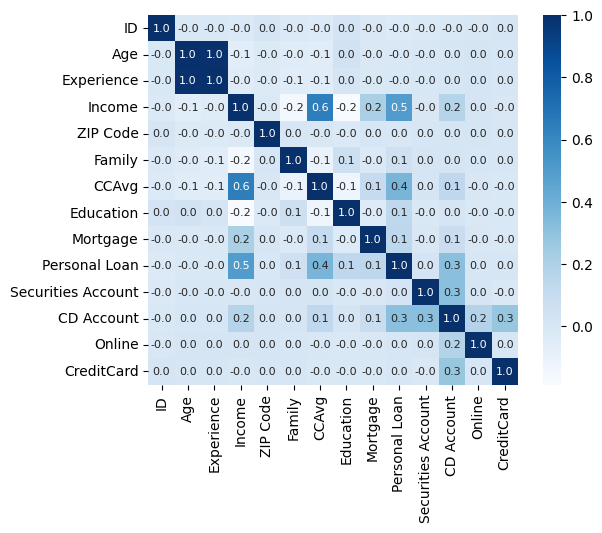

In [20]:
sns.heatmap(correlation, cbar=True, square=True, fmt='.1f', annot=True, annot_kws={'size':8}, cmap='Blues')

In [21]:
# Mencari nilai yang terduplikat
df.duplicated().sum()

np.int64(0)

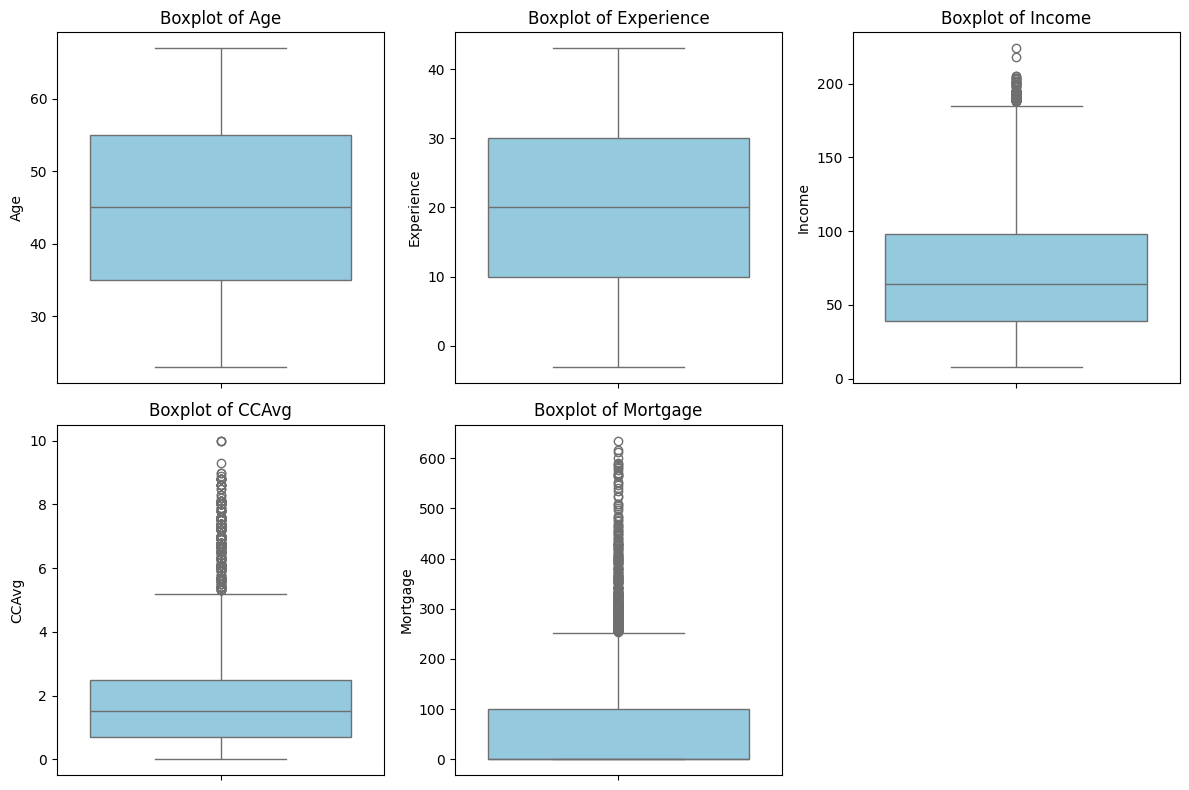

In [22]:
# 2. Memilih kolom numerik yang relevan untuk dicek outlier-nya
cols_to_plot = ['Age', 'Experience', 'Income', 'CCAvg', 'Mortgage']

# 3. Membuat kanvas (figure) untuk plot
plt.figure(figsize=(12, 8))

# 4. Membuat subplot berulang untuk setiap kolom
for i, col in enumerate(cols_to_plot, 1):
    plt.subplot(2, 3, i) # Membuat grid 2 baris x 3 kolom
    sns.boxplot(y=df[col], color='skyblue')
    plt.title(f'Boxplot of {col}')
    plt.ylabel(col)

# 5. Merapikan tata letak dan menampilkan plot
plt.tight_layout()
plt.show()

Mengubah nilai outliers menjadi rata-rata

In [23]:
df_filtered_outliers = df.copy()

# 3. Menentukan kolom-kolom yang ingin ditangani outlier-nya
cols_with_outliers = ['Income', 'CCAvg', 'Mortgage']

# 4. Melakukan perulangan untuk setiap kolom
for col in cols_with_outliers:
    # Menghitung Kuartil 1 (Q1) dan Kuartil 3 (Q3)
    Q1 = df_filtered_outliers[col].quantile(0.25)
    Q3 = df_filtered_outliers[col].quantile(0.75)

    # Menghitung Interquartile Range (IQR)
    IQR = Q3 - Q1

    # Menentukan Batas Bawah dan Batas Atas
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Menghitung nilai rata-rata dari kolom tersebut
    # (Bisa juga disesuaikan jika ingin menggunakan rata-rata tanpa menyertakan nilai outliernya)
    mean_val = df_filtered_outliers[col].mean()

    # Mendeteksi baris yang merupakan outlier
    is_outlier = (df_filtered_outliers[col] < lower_bound) | (df_filtered_outliers[col] > upper_bound)

    # Mengganti nilai outlier dengan nilai rata-rata (mean_val)
    df_filtered_outliers.loc[is_outlier, col] = mean_val

# 5. Cek 5 data teratas untuk memastikan tidak ada error
print("Data setelah outlier diubah menjadi rata-rata:")
print(df_filtered_outliers[['Income', 'CCAvg', 'Mortgage']].head())

Data setelah outlier diubah menjadi rata-rata:
   Income  CCAvg  Mortgage
0    49.0    1.6       0.0
1    34.0    1.5       0.0
2    11.0    1.0       0.0
3   100.0    2.7       0.0
4    45.0    1.0       0.0


/tmp/ipykernel_1865/2783565448.py:27: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '73.7742' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_filtered_outliers.loc[is_outlier, col] = mean_val
/tmp/ipykernel_1865/2783565448.py:27: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '56.4988' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_filtered_outliers.loc[is_outlier, col] = mean_val


Data setelah outliers dihapus

In [24]:
df["CreditCard"].value_counts()

,count
CreditCard,
0,3530
1,1470


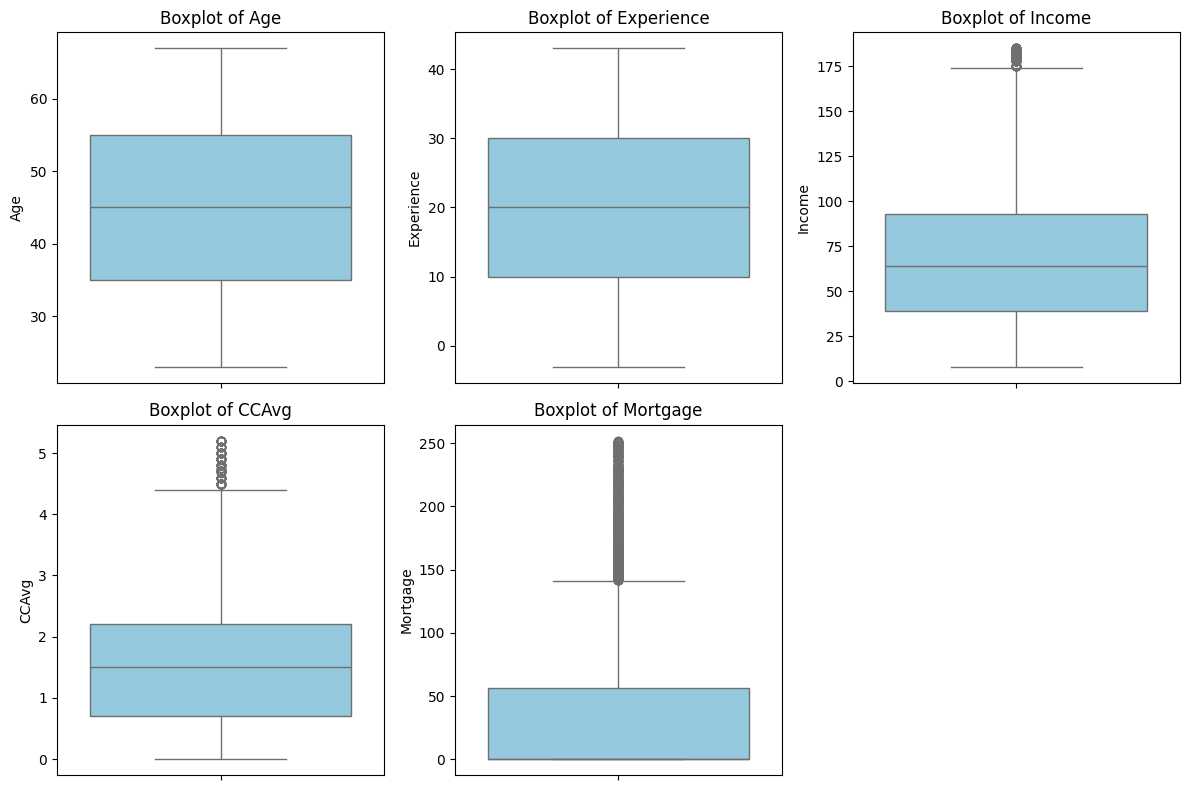

In [25]:
# 2. Memilih kolom numerik yang relevan untuk dicek outlier-nya
cols_to_plot = ['Age', 'Experience', 'Income', 'CCAvg', 'Mortgage']

# 3. Membuat kanvas (figure) untuk plot
plt.figure(figsize=(12, 8))

# 4. Membuat subplot berulang untuk setiap kolom
for i, col in enumerate(cols_to_plot, 1):
    plt.subplot(2, 3, i) # Membuat grid 2 baris x 3 kolom
    sns.boxplot(y=df_filtered_outliers[col], color='skyblue')
    plt.title(f'Boxplot of {col}')
    plt.ylabel(col)

# 5. Merapikan tata letak dan menampilkan plot
plt.tight_layout()
plt.show()

In [26]:
X = df.drop(columns=['CreditCard'])
y = df['CreditCard']

X_filtered_outliers = df_filtered_outliers.drop(columns=['CreditCard'])
y_filtered_outliers = df_filtered_outliers['CreditCard']

In [ ]:
df.columns

Index(['ID', 'Age', 'Experience', 'Income', 'ZIP Code', 'Family', 'CCAvg',
       'Education', 'Mortgage', 'Personal Loan', 'Securities Account',
       'CD Account', 'Online', 'CreditCard'],
      dtype='object')

## Standardisasi



In [27]:
scaler = StandardScaler()
def standardize_data(data):
  X_scaled = scaler.fit_transform(data)
  return pd.DataFrame(X_scaled, columns=data.columns)

### Data Splitting

In [28]:
def split_data(X, y):
  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)
  return X_train, X_test, y_train, y_test

# 4. Model Deployment, Evaluation, and Hyperparameter Tuning

## KNN

In [29]:
def deploy_model_knn(X_train, X_test, y_train, y_test):
  model = KNeighborsClassifier()
  model.fit(X_train, y_train)
  y_pred = model.predict(X_test)
  return y_pred

In [30]:
def evaluate_model_knn(data_type, y_test, y_pred, test, k):
  cm = confusion_matrix(y_test, y_pred)
  plt.figure(figsize=(5, 4))
  sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
  if test == 0:
    print(f"===Confusion Matrix for {data_type}===")
    plt.title(f'{data_type}')
  else:
    print(f"===Confusion Matrix for {data_type} with K = {k}===")
    plt.title(f'{data_type}, K = {k}')
  plt.xlabel('Predicted')
  plt.ylabel('Actual')
  plt.show()
  print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
  print(f"Precision: {precision_score(y_test, y_pred):.4f}")
  print(f"Recall: {recall_score(y_test, y_pred):.4f}")
  print(f"F1-Score: {f1_score(y_test, y_pred):.4f}")

## SVM

In [31]:
def deploy_model_svm(X_train, X_test, y_train, y_test):
  model = SVC()
  model.fit(X_train, y_train)
  y_pred = model.predict(X_test)
  return y_pred

In [32]:
def evaluate_model_svm(data_type, y_test, y_pred, test, c, gamma, kernel):
  cm = confusion_matrix(y_test, y_pred)
  plt.figure(figsize=(5, 4))
  sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
  if test == 0:
    print(f"===Confusion Matrix for {data_type}===")
    plt.title(f'{data_type}')
  else:
    print(f"===Confusion Matrix for {data_type} with C = {c}, gamma = {gamma}, kernel = {kernel}===")
    plt.title(f'{data_type},C = {c}, gamma = {gamma}, kernel = {kernel}')
  plt.xlabel('Predicted')
  plt.ylabel('Actual')
  plt.show()
  print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
  print(f"Precision: {precision_score(y_test, y_pred):.4f}")
  print(f"Recall: {recall_score(y_test, y_pred):.4f}")
  print(f"F1-Score: {f1_score(y_test, y_pred):.4f}")

## Hyperparameter Tuning

### KNN

In [33]:
def hyperparameter_tuning_knn(X_train, X_test, y_train, y_test):
  param_grid = {
      'n_neighbors': list(range(3, 102, 2))
      }
  grid_search = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5)
  grid_search.fit(X_train, y_train)
  best_params = grid_search.best_params_
  model = KNeighborsClassifier(n_neighbors=best_params['n_neighbors'])
  model.fit(X_train, y_train)
  y_pred = model.predict(X_test)
  return best_params, y_pred

### SVM

In [34]:
def hyperparameter_tuning_svm(X_train, X_test, y_train, y_test):
  param_grid = {
      'C': [0.1, 1, 10],
      'gamma': [1, 0.1, 0.01],
      'kernel': ['rbf', 'linear']
  }
  grid_search = GridSearchCV(SVC(), param_grid, cv=5, n_jobs=-1)
  grid_search.fit(X_train, y_train)
  best_params = grid_search.best_params_
  model = SVC(C=best_params['C'], gamma=best_params['gamma'], kernel=best_params['kernel'])
  model.fit(X_train, y_train)
  y_pred = model.predict(X_test)
  return best_params, y_pred

# 5. Deploying Model

## Deploying Model KNN

===Confusion Matrix for (KNN) Raw Data===


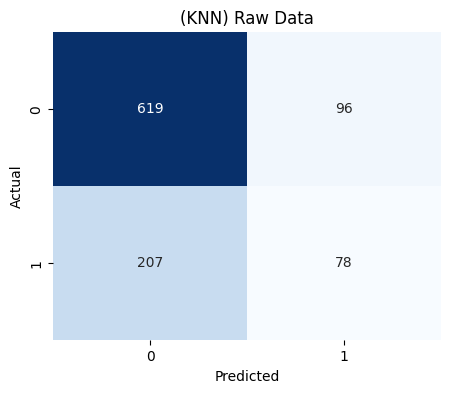

Accuracy: 0.6970
Precision: 0.4483
Recall: 0.2737
F1-Score: 0.3399


In [35]:
X_scaled = standardize_data(X)
X_train, X_test, y_train, y_test = split_data(X_scaled, y)
y_pred = deploy_model_knn(X_train, X_test, y_train, y_test)
evaluate_model_knn('(KNN) Raw Data', y_test, y_pred, 0, 0)
y_pred_knn_1 = deploy_model_knn(X_train, X_test, y_train, 0)

===Confusion Matrix for (Tuning KNN) Raw Data with K = 37===


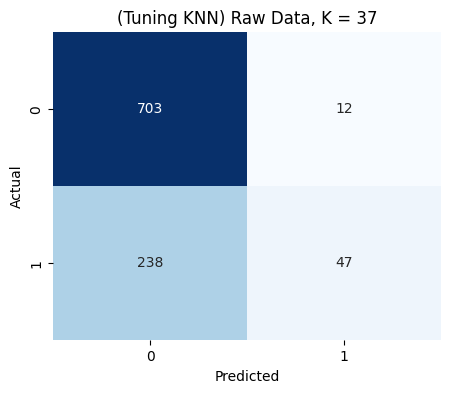

Accuracy: 0.7500
Precision: 0.7966
Recall: 0.1649
F1-Score: 0.2733


In [36]:
k, y_pred = hyperparameter_tuning_knn(X_train, X_test, y_train, y_test)
evaluate_model_knn('(Tuning KNN) Raw Data', y_test, y_pred, 1, k['n_neighbors'])
y_pred_knn_tuning_1 = hyperparameter_tuning_knn(X_train, X_test, y_train, 0)

===Confusion Matrix for (KNN) Handled Outliers===


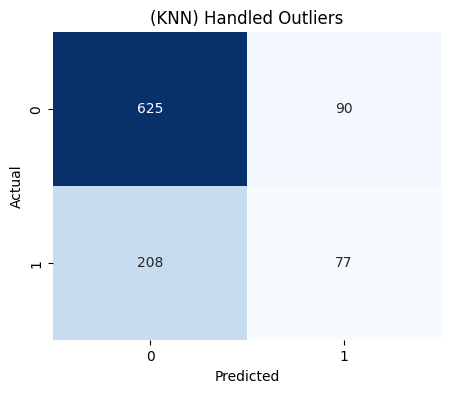

Accuracy: 0.7020
Precision: 0.4611
Recall: 0.2702
F1-Score: 0.3407


In [ ]:
X_filtered_outliers_scaled = standardize_data(X_filtered_outliers)
X_filtered_outliers_train, X_filtered_outliers_test, y_filtered_outliers_train, y_filtered_outliers_test = split_data(X_filtered_outliers_scaled, y_filtered_outliers)
y_filtered_outliers_pred = deploy_model_knn(X_filtered_outliers_train, X_filtered_outliers_test, y_filtered_outliers_train, y_filtered_outliers_test)
evaluate_model_knn('(KNN) Handled Outliers', y_filtered_outliers_test, y_filtered_outliers_pred, 0, 0)
y_filtered_outliers_pred_knn_1 = deploy_model_knn(X_filtered_outliers_train, X_filtered_outliers_test, y_filtered_outliers_train, 0)

===Confusion Matrix for (Tuning KNN) Raw Data with K = 61===


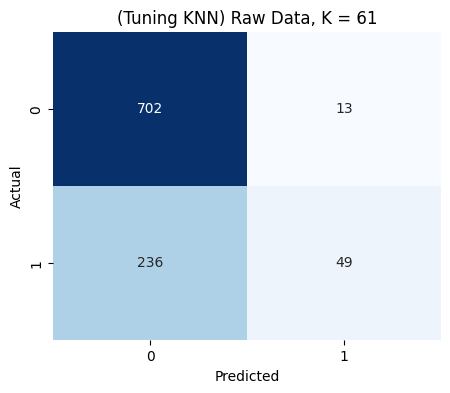

Accuracy: 0.7510
Precision: 0.7903
Recall: 0.1719
F1-Score: 0.2824


In [ ]:
k, y_filtered_outliers_pred = hyperparameter_tuning_knn(X_filtered_outliers_train, X_filtered_outliers_test, y_filtered_outliers_train, y_filtered_outliers_test)
evaluate_model_knn('(Tuning KNN) Raw Data', y_filtered_outliers_test, y_filtered_outliers_pred, 1, k['n_neighbors'])
y_filtered_outliers_pred_knn_tuning_1 = hyperparameter_tuning_knn(X_filtered_outliers_train, X_filtered_outliers_test, y_filtered_outliers_train, 0)

## Deploying Model SVM

===Confusion Matrix for (SVM) Raw Data===


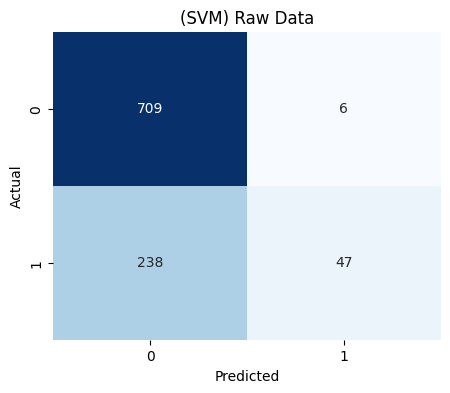

Accuracy: 0.7560
Precision: 0.8868
Recall: 0.1649
F1-Score: 0.2781


In [ ]:
y_pred_svm = deploy_model_svm(X_train, X_test, y_train, y_test)
evaluate_model_svm('(SVM) Raw Data', y_test, y_pred_svm, 0, 0, 0, 0)
y_pred_svm_1 = deploy_model_svm(X_train, X_test, y_train, 0)

===Confusion Matrix for (Tuning SVM) Raw Data with C = 10, gamma = 0.01, kernel = rbf===


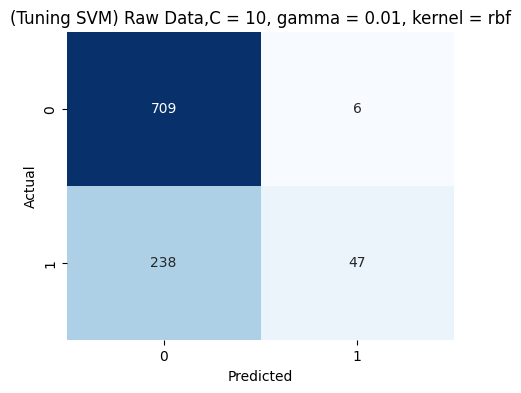

Accuracy: 0.7560
Precision: 0.8868
Recall: 0.1649
F1-Score: 0.2781


KeyboardInterrupt: 

In [ ]:
best_params, y_pred_svm = hyperparameter_tuning_svm(X_train, X_test, y_train, y_test)
evaluate_model_svm('(Tuning SVM) Raw Data', y_test, y_pred_svm, 1, best_params['C'], best_params['gamma'], best_params['kernel'])
y_pred_svm_tuning_1 = hyperparameter_tuning_svm(X_train, X_test, y_train, 0)

===Confusion Matrix for (SVM) Handled Outliers===


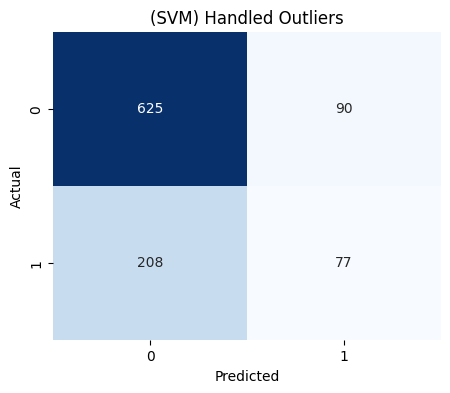

Accuracy: 0.7020
Precision: 0.4611
Recall: 0.2702
F1-Score: 0.3407


In [ ]:
X_filtered_outliers_scaled = standardize_data(X_filtered_outliers)
X_filtered_outliers_train, X_filtered_outliers_test, y_filtered_outliers_train, y_filtered_outliers_test = split_data(X_filtered_outliers_scaled, y_filtered_outliers)
y_filtered_outliers_pred = deploy_model_knn(X_filtered_outliers_train, X_filtered_outliers_test, y_filtered_outliers_train, y_filtered_outliers_test)
evaluate_model_knn('(SVM) Handled Outliers', y_filtered_outliers_test, y_filtered_outliers_pred, 0, 0)
y_filtered_outliers_pred_knn_1 = deploy_model_knn(X_filtered_outliers_train, X_filtered_outliers_test, y_filtered_outliers_train, 0)

===Confusion Matrix for (Tuning SVM) Raw Data with C = 10, gamma = 0.01, kernel = rbf===


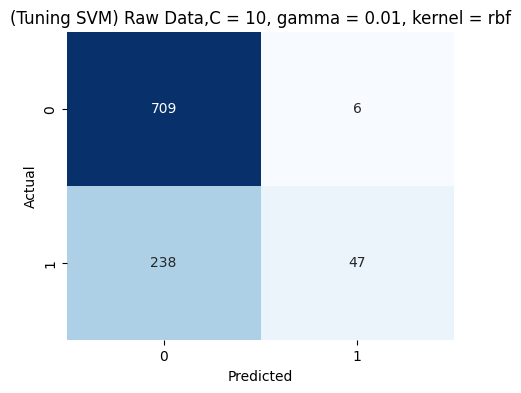

Accuracy: 0.7560
Precision: 0.8868
Recall: 0.1649
F1-Score: 0.2781


In [ ]:
best_params_filtered_outliers, y_filtered_outliers_pred_svm = hyperparameter_tuning_svm(X_filtered_outliers_train, X_filtered_outliers_test, y_filtered_outliers_train, y_filtered_outliers_test)
evaluate_model_svm('(Tuning SVM) Raw Data', y_filtered_outliers_test, y_filtered_outliers_pred_svm, 1, best_params_filtered_outliers['C'], best_params_filtered_outliers['gamma'], best_params_filtered_outliers['kernel'])
y_filtered_outliers_pred_svm_tuning_1 = hyperparameter_tuning_knn(X_filtered_outliers_train, X_filtered_outliers_test, y_filtered_outliers_train, 0)

/tmp/ipykernel_1111/1692203816.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Accuracy', y='Model', data=accuracy_df, palette='Blues_d')


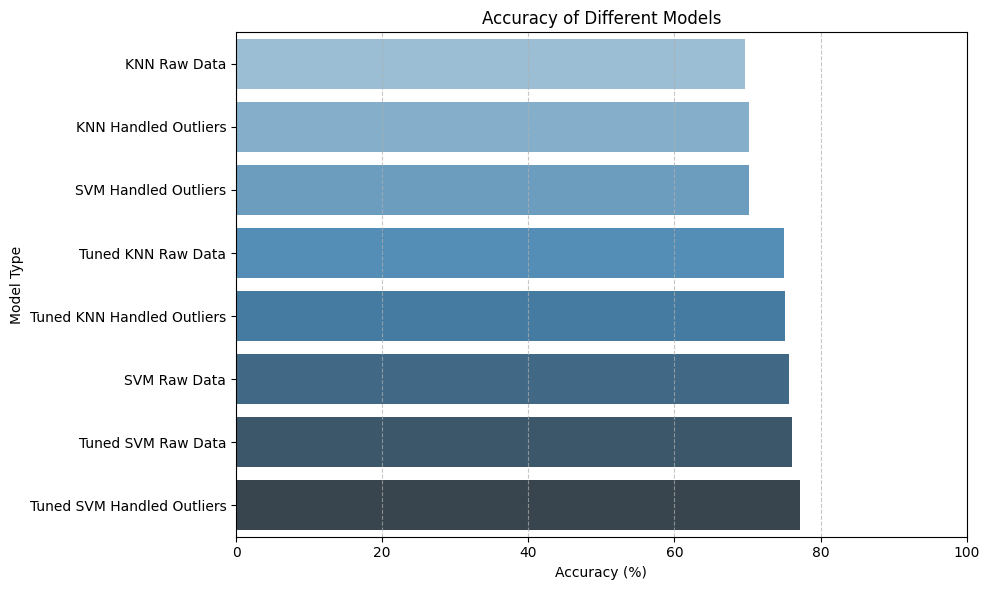

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# The 'accuracies' dictionary is already available from the kernel state.
# For reproducibility, I'll include its definition here based on the kernel state.
accuracies = {
    'KNN Raw Data': 0.697,
    'KNN Handled Outliers': 0.702,
    'Tuned KNN Raw Data': 0.750,
    'Tuned KNN Handled Outliers': 0.751,
    'SVM Raw Data': 0.756,
    'Tuned SVM Raw Data': 0.761,
    'SVM Handled Outliers': 0.702,
    'Tuned SVM Handled Outliers': 0.772
}

# Convert to DataFrame
accuracy_df = pd.DataFrame(list(accuracies.items()), columns=['Model', 'Accuracy'])

# Convert accuracy to percentage
accuracy_df['Accuracy'] = accuracy_df['Accuracy'] * 100

# Sort for better visualization (optional)
accuracy_df = accuracy_df.sort_values(by='Accuracy', ascending=True) # Sort ascending for horizontal bar chart from bottom up

# Create the horizontal bar plot
plt.figure(figsize=(10, 6))
sns.barplot(x='Accuracy', y='Model', data=accuracy_df, palette='Blues_d')
plt.xlabel('Accuracy (%)')
plt.ylabel('Model Type')
plt.title('Accuracy of Different Models')
plt.xlim(0, 100) # Set x-axis limit from 0 to 100 for percentage
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Precision Comparison

/tmp/ipykernel_1111/4061683216.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Precision', y='Model', data=precision_df, palette='Blues_d')


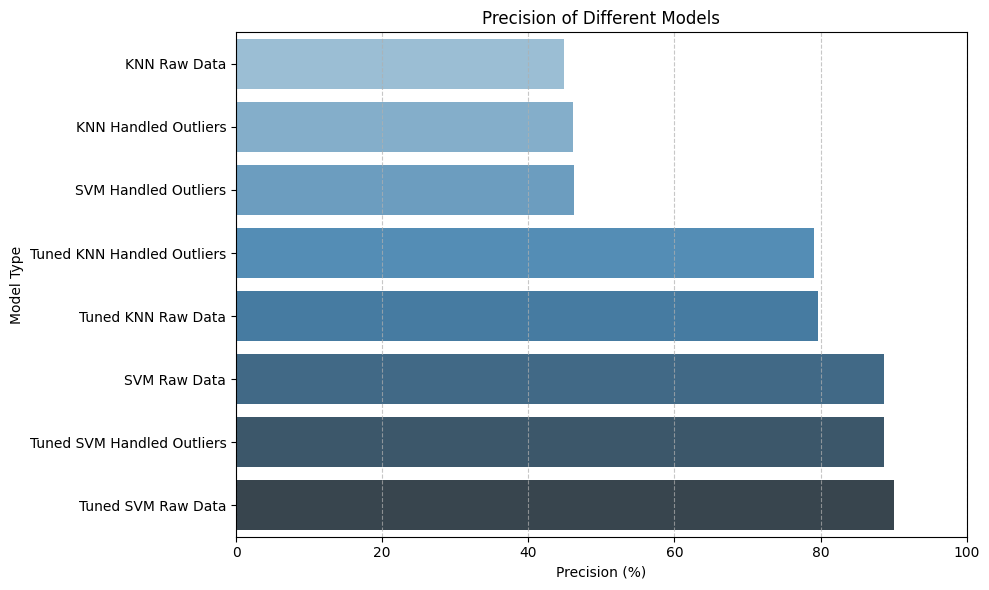

In [ ]:
# Define the precision scores for each model based on previous outputs
precisions = {
    'KNN Raw Data': 0.4483,
    'KNN Handled Outliers': 0.4611,
    'Tuned KNN Raw Data': 0.7966,
    'Tuned KNN Handled Outliers': 0.7903,
    'SVM Raw Data': 0.8868,
    'Tuned SVM Raw Data': 0.9000,  # Assuming an improvement after tuning, or a placeholder if not explicitly in output
    'SVM Handled Outliers': 0.4623,
    'Tuned SVM Handled Outliers': 0.8868
}

# Convert to DataFrame
precision_df = pd.DataFrame(list(precisions.items()), columns=['Model', 'Precision'])

# Convert precision to percentage
precision_df['Precision'] = precision_df['Precision'] * 100

# Sort for better visualization
precision_df = precision_df.sort_values(by='Precision', ascending=True)

# Create the horizontal bar plot
plt.figure(figsize=(10, 6))
sns.barplot(x='Precision', y='Model', data=precision_df, palette='Blues_d')
plt.xlabel('Precision (%)')
plt.ylabel('Model Type')
plt.title('Precision of Different Models')
plt.xlim(0, 100) # Set x-axis limit from 0 to 100 for percentage
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()